# *Libraries import*

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

# *Dataset path*

In [2]:
DATASET_DIR = Path("../dataset/RDD_SPLIT")

TRAIN_DIR = DATASET_DIR / "train"
VAL_DIR = DATASET_DIR / "val"
TEST_DIR = DATASET_DIR / "test"

print("Dataset path:", DATASET_DIR)
print("Train path:", TRAIN_DIR)
print("Validation path:", VAL_DIR)
print("Test path:", TEST_DIR)

Dataset path: ..\dataset\RDD_SPLIT
Train path: ..\dataset\RDD_SPLIT\train
Validation path: ..\dataset\RDD_SPLIT\val
Test path: ..\dataset\RDD_SPLIT\test


# *Dataset folders*

In [3]:
print("Train exists:", TRAIN_DIR.exists())
print("Validation exists:", VAL_DIR.exists())
print("Test exists:", TEST_DIR.exists())

Train exists: True
Validation exists: True
Test exists: True


# *Train/Val/Test structure check*

In [4]:
for split_name, split_dir in {
    "Train": TRAIN_DIR,
    "Validation": VAL_DIR,
    "Test": TEST_DIR
}.items():

    print("\n" + "=" * 50)
    print(split_name)
    print("=" * 50)

    if split_dir.exists():
        print("Folders:", [x.name for x in split_dir.iterdir()])


Train
Folders: ['images', 'labels']

Validation
Folders: ['images', 'labels']

Test
Folders: ['images', 'labels']


# *Images and labels count*

In [5]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}

def count_files(folder):
    images = []
    labels = []

    if folder.exists():
        for file in folder.rglob("*"):
            if file.is_file():
                if file.suffix.lower() in IMAGE_EXTENSIONS:
                    images.append(file)
                elif file.suffix.lower() == ".txt":
                    labels.append(file)

    return images, labels


for split_name, split_dir in {
    "Train": TRAIN_DIR,
    "Validation": VAL_DIR,
    "Test": TEST_DIR
}.items():

    images, labels = count_files(split_dir)

    print(f"\n{split_name}")
    print("-" * 30)
    print("Images:", len(images))
    print("Labels:", len(labels))


Train
------------------------------
Images: 26869
Labels: 26869

Validation
------------------------------
Images: 5758
Labels: 5758

Test
------------------------------
Images: 5758
Labels: 5758


# *Find Sample images*

In [6]:
train_images, train_labels = count_files(TRAIN_DIR)

print("Total training images:", len(train_images))

if len(train_images) > 0:
    print("\nFirst 10 training images:")
    
    for image_path in train_images[:10]:
        print(image_path)

Total training images: 26869

First 10 training images:
..\dataset\RDD_SPLIT\train\images\China_Drone_000001.jpg
..\dataset\RDD_SPLIT\train\images\China_Drone_000002.jpg
..\dataset\RDD_SPLIT\train\images\China_Drone_000003.jpg
..\dataset\RDD_SPLIT\train\images\China_Drone_000005.jpg
..\dataset\RDD_SPLIT\train\images\China_Drone_000009.jpg
..\dataset\RDD_SPLIT\train\images\China_Drone_000010.jpg
..\dataset\RDD_SPLIT\train\images\China_Drone_000011.jpg
..\dataset\RDD_SPLIT\train\images\China_Drone_000012.jpg
..\dataset\RDD_SPLIT\train\images\China_Drone_000014.jpg
..\dataset\RDD_SPLIT\train\images\China_Drone_000015.jpg


# *Display Image Sample*

Image: China_Drone_000001.jpg
Original shape: (512, 512, 3)


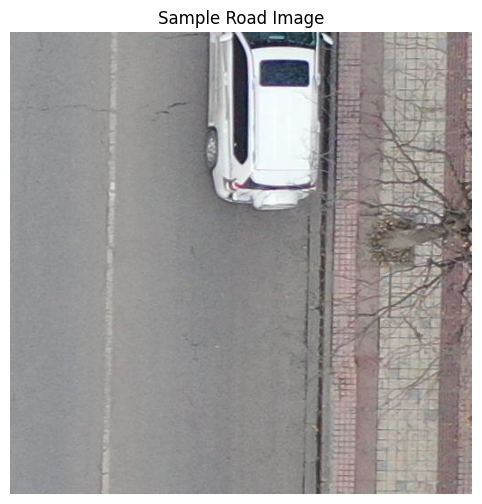

In [7]:
if len(train_images) > 0:

    sample_image_path = train_images[0]

    image = cv2.imread(str(sample_image_path))
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    print("Image:", sample_image_path.name)
    print("Original shape:", image_rgb.shape)

    plt.figure(figsize=(10, 6))
    plt.imshow(image_rgb)
    plt.axis("off")
    plt.title("Sample Road Image")
    plt.show()

# *Image dimensions*

In [8]:
image_sizes = []

for image_path in train_images[:100]:

    image = cv2.imread(str(image_path))

    if image is not None:
        height, width = image.shape[:2]
        image_sizes.append((width, height))


print("Number of images checked:", len(image_sizes))

if image_sizes:
    print("First 10 image sizes:")
    print(image_sizes[:10])

Number of images checked: 100
First 10 image sizes:
[(512, 512), (512, 512), (512, 512), (512, 512), (512, 512), (512, 512), (512, 512), (512, 512), (512, 512), (512, 512)]


# *Resize example*

Original shape: (512, 512, 3)
Resized shape: (640, 640, 3)


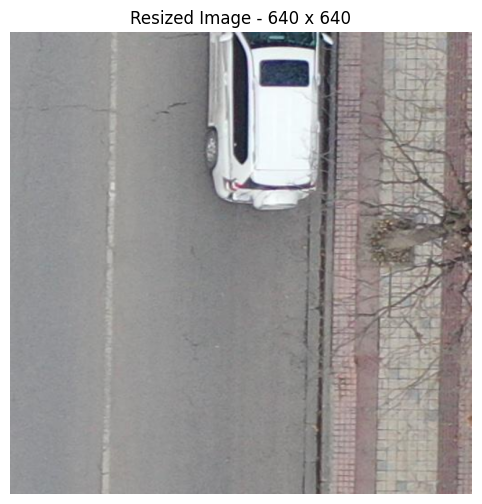

In [9]:
if len(train_images) > 0:

    image = cv2.imread(str(train_images[0]))
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    resized_image = cv2.resize(
        image_rgb,
        (640, 640)
    )

    print("Original shape:", image_rgb.shape)
    print("Resized shape:", resized_image.shape)

    plt.figure(figsize=(8, 6))
    plt.imshow(resized_image)
    plt.axis("off")
    plt.title("Resized Image - 640 x 640")
    plt.show()

# *Normalization example*

In [10]:
normalized_image = resized_image.astype(np.float32) / 255.0

print("Minimum pixel value:", normalized_image.min())
print("Maximum pixel value:", normalized_image.max())
print("Data type:", normalized_image.dtype)

Minimum pixel value: 0.03137255
Maximum pixel value: 1.0
Data type: float32


# *Annotation file*

In [11]:
if len(train_images) > 0:

    sample_image = train_images[0]
    label_file = sample_image.with_suffix(".txt")

    print("Image:", sample_image.name)
    print("Expected label:", label_file.name)
    print("Label exists:", label_file.exists())

    if label_file.exists():
        print("\nLabel content:")
        print(label_file.read_text()[:1000])

Image: China_Drone_000001.jpg
Expected label: China_Drone_000001.txt
Label exists: False


## Dataset Classes

The road damage detection dataset used in this project contains five detection classes.

| Class ID | Class |
| -------: | ----- |
|        0 | D00   |
|        1 | D10   |
|        2 | D20   |
|        3 | D40   |
|        4 | D43   |

These class labels are used by the YOLO object detection model.


# *Count Class IDs*

In [ ]:
from collections import Counter

class_counts = Counter()

for label_file in train_labels:

    try:
        with open(label_file, "r") as f:

            for line in f:
                parts = line.strip().split()

                if len(parts) >= 5:
                    class_id = int(parts[0])
                    class_counts[class_id] += 1

    except Exception:
        pass


print("Class distribution in training annotations:")

for class_id, count in sorted(class_counts.items()):
    print(f"Class {class_id}: {count}")

Class distribution in training annotations:
Class 0: 18201
Class 1: 8386
Class 2: 7527
Class 3: 7554
Class 4: 4628


: 

## ✅ Data Preparation Summary

The RDD2022 road damage dataset was inspected and prepared for deep learning model development.

The following steps were completed:

* Dataset directory structure verified
* Training, validation, and testing folders checked
* Road images identified
* Annotation files verified
* Image dimensions inspected
* Image resizing demonstrated
* Pixel normalization demonstrated
* Damage class IDs verified
* Training annotations inspected

The prepared dataset is ready for further analysis and model training.
